# Phần 5.2 Xây dựng và đánh giá mô hình hồi quy tuyến tính đa biến

### Chuẩn bị thư viện và kiểm tra dữ liệu

In [21]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.dummy import DummyRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



warnings.filterwarnings("ignore", category=RuntimeWarning)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})

candidate_paths = [
    Path("../EDA/cleaned_data/hour_cleaned.csv"),
    Path("EDA/cleaned_data/hour_cleaned.csv"),
    Path.cwd().parent / "EDA/cleaned_data/hour_cleaned.csv",
]
DATA_PATH = next((path for path in candidate_paths if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy EDA/cleaned_data/hour_cleaned.csv")

df = pd.read_csv(DATA_PATH)
unnamed_columns = [column for column in df.columns if column.lower().startswith("unnamed")]
df = df.drop(columns=unnamed_columns)
df["dteday"] = pd.to_datetime(df["dteday"], errors="raise")

print(f"Đầu vào: {DATA_PATH.resolve()}")
print(f"Kích thước: {df.shape[0]:,} dòng x {df.shape[1]} biến")
print(f"Cột index dư thừa đã loại: {unnamed_columns or 'không có'}")
print(f"Giá trị thiếu: {int(df.isna().sum().sum())}")
display(df.head())

Đầu vào: D:\phannguyenchuong\Code_Python\Workshop\Data_Analytic_and_Visualization_BikeSharing_W.DC-main\EDA\cleaned_data\hour_cleaned.csv
Kích thước: 17,379 dòng x 17 biến
Cột index dư thừa đã loại: không có
Giá trị thiếu: 0


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Phần 5.2.1 Xác định mục tiêu

**Biến mục tiêu:** `cnt`

**Biến đầu vào:** 
- mục tiêu: `cnt`
- thời tiết: `temp`,`hum`,`windspeed`
- Thời gian: `hr`, `weekday`, `mnth`, `season`
- Lịch:	`holiday`, `workingday`, `yr`
- Điều kiện thời tiết: `weathersit`

**Biến loại bỏ:**
- `instant`, `dteday`: Chỉ là biến định danh
- `atemp`: Cộng tuyến nặng với biến `temp`
- `casual`, `registered`: Tránh rò rỉ dữ liệu

**Kết quả cần đạt:** Xây dựng mô hình, dự đoán trên dữ liệu chưa dùng để huấn luyện, tính các chỉ số đánh giá và giải thích mức độ hữu ích cũng như hạn chế của mô hình.

In [22]:
df = df.drop(["instant","dteday","atemp","casual","registered"], axis=1)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      17379 non-null  int64  
 1   yr          17379 non-null  int64  
 2   mnth        17379 non-null  int64  
 3   hr          17379 non-null  int64  
 4   holiday     17379 non-null  int64  
 5   weekday     17379 non-null  int64  
 6   workingday  17379 non-null  int64  
 7   weathersit  17379 non-null  int64  
 8   temp        17379 non-null  float64
 9   hum         17379 non-null  float64
 10  windspeed   17379 non-null  float64
 11  cnt         17379 non-null  int64  
dtypes: float64(3), int64(9)
memory usage: 1.6 MB


### 5.2.2. Chia dữ liệu train và test

Vì dữ liệu có hơn 17,000 dòng, ta dùng 90% dữ liệu đầu tiên để huấn luyện và 10% cuối cùng để kiểm tra, thay vì chia ngẫu nhiên.

In [23]:
target = "cnt"

numeric_features = [
    "temp", "hum", "windspeed", "yr",
    "holiday", "workingday"
]

categorical_features = [
    "season", "mnth", "hr", "weekday", "weathersit"
]

feature_cols = numeric_features + categorical_features

X = df[feature_cols]
y = df[target]

split_idx = int(len(df) * 0.9)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (15641, 11)
Test: (1738, 11)


### 5.2.3. Xây dựng và huấn luyện mô hình

Các biến như `hr`, `mnth`, `weekday`, `season` và `weathersit` là các mã phân loại, không nên mặc định rằng chúng có quan hệ tuyến tính theo giá trị số. Ta dùng `OneHotEncoder` để biểu diễn chúng thành các biến chỉ báo.

In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", numeric_features),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)

print("Huấn luyện mô hình hoàn tất.")

Huấn luyện mô hình hoàn tất.


### 5.2.4. Dự đoán và đánh giá mô hình

Sau khi huấn luyện, ta dự đoán trên tập test và sử dụng ba chỉ số:
1. MAE
2. RMSE
3. $R^2$

In [25]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [mae, rmse, r2]
})

print(metrics.to_string(index=False))

Metric      Value
   MAE  85.523027
  RMSE 116.402997
    R²   0.616317


Tạo mô hình baseline tính bằng `mean` để so sánh với mô hình MLR

In [26]:
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

print("Baseline MAE:", mean_absolute_error(y_test, baseline_pred))
print("Baseline RMSE:", np.sqrt(mean_squared_error(y_test, baseline_pred)))
print("Baseline R²:", r2_score(y_test, baseline_pred))

Baseline MAE: 147.6173800100044
Baseline RMSE: 188.53660442113605
Baseline R²: -0.006549721673292375


Model|Mean|Multiple Linear Regression
---|---|---
MAE|147.6173800100044|85.523027
RMSE|188.53660442113605|116.402997
R²|-0.006549721673292375|0.616317

### 5.2.5. Trực quan hóa kết quả

so sánh giá trị thực tế và giá trị dự đoán.

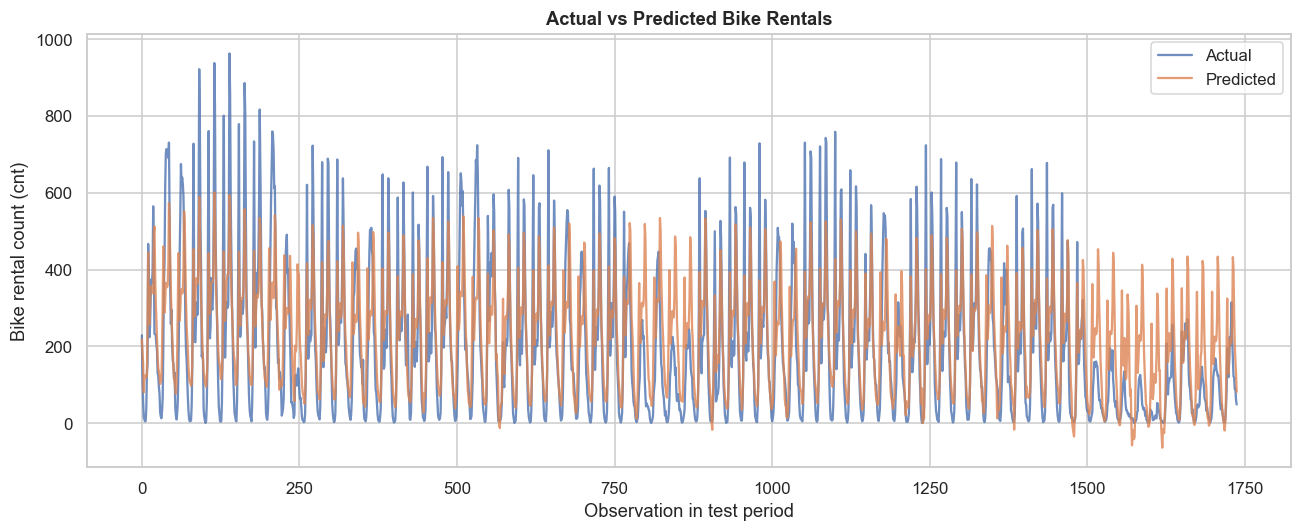

In [27]:
plt.figure(figsize=(12, 5))

plt.plot(
    np.arange(len(y_test)),
    y_test.to_numpy(),
    label="Actual",
    alpha=0.8
)

plt.plot(
    np.arange(len(y_pred)),
    y_pred,
    label="Predicted",
    alpha=0.8
)

plt.xlabel("Observation in test period")
plt.ylabel("Bike rental count (cnt)")
plt.title("Actual vs Predicted Bike Rentals")
plt.legend()
plt.tight_layout()
plt.show()

### 5.2.6. kiểm tra phần dư - chênh lệch giữa giá trị thực tế và dự đoán:

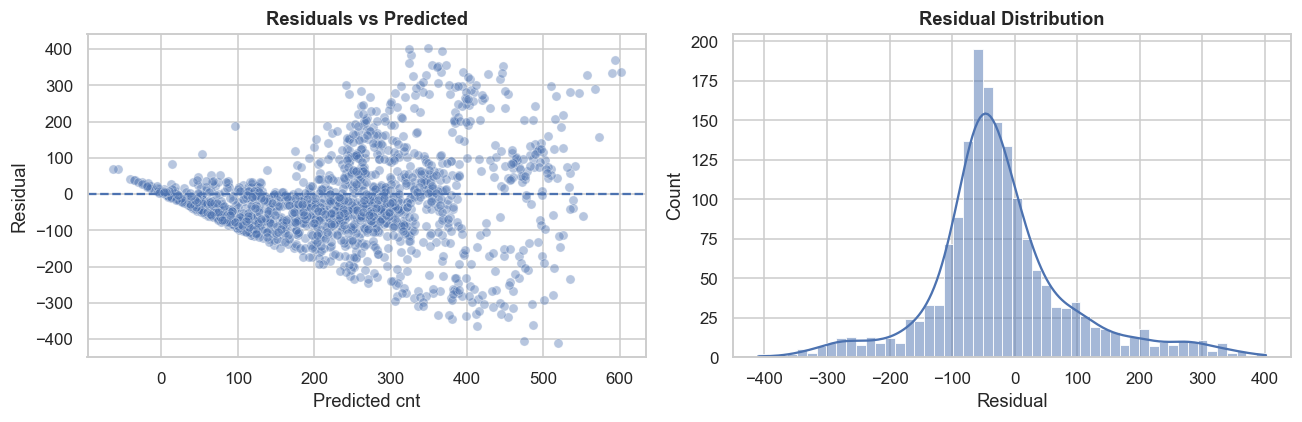

In [28]:
residuals = y_test.to_numpy() - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(x=y_pred, y=residuals, alpha=0.4, ax=axes[0])
axes[0].axhline(0, linestyle="--")
axes[0].set_xlabel("Predicted cnt")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted")

sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()

### Nhận xét:
**Residuals vs Predicted**
1. Hình phễu:
  - Điểm dữ liệu tập trung hẹp quanh vạch 0 khi Predicted `cnt` nhỏ, nhưng xòe rộng ra đáng kể khi Predicted `cnt` lớn.

  
  -> Độ chính xác của mô hình không đồng đều. Mô hình dự đoán tương đối ổn ở các giá trị nhỏ, nhưng dự đoán kém và dao động rất mạnh khi giá trị thực tế/dự đoán tăng cao.

  
2. Đường biên chéo bên dưới:
  - đường biên sắc nét chặn phía dưới kéo dài nghiêng xuống. Nguyên nhân là do biến mục tiêu cnt (số lượng) luôn $\ge 0$. Khi $y \ge 0$, ta luôn có $Residual = y - \hat{y} \ge -\hat{y}$.

3. Dự đoán ra giá trị âm:
  - rục $X$ kéo dài sang phía âm (khoảng $-80$ đến $0$). Việc mô hình hồi quy tuyến tính dự đoán ra số lượng đếm âm là vô lý về mặt thực tế.

**Residual Distribution**
Biểu đồ này kiểm tra giả định Phần dư tuân theo Phân phối chuẩn

1. Lệch đỉnh: Đỉnh của phân phối không nằm tại 0 mà lệch sang khoảng $-50$. Điều này cho thấy mô hình có xu hướng dự đoán cao hơn giá trị thực tế ở số lượng lớn các mẫu.
2. Đuôi dài và không chuẩn:
- Phân phối có đuôi kéo dài về bên phải ($+300$ đến $+400$) và có thêm một cụm phụ dàn trải về bên trái ($-200$ đến $-300$).


-> Phần dư không tuân theo hình chuông chuẩn $N(0, \sigma^2)$, làm giảm độ tin cậy của các khoảng tin cậy (Confidence Intervals) và kiểm định p-value của mô hình.


### 5.2.7. Nhận xét và hạn chế:

Để đánh giá hiệu quả của mô hình Multiple Linear Regression, nghiên cứu sử dụng mô hình DummyRegressor với chiến lược `mean` làm mô hình Baseline. Baseline dự đoán số lượng xe thuê bằng giá trị trung bình của biến mục tiêu trong tập huấn luyện, qua đó cung cấp một mốc so sánh cơ bản cho mô hình hồi quy.

Model|Mean|Multiple Linear Regression
---|---|---
MAE|147.6173800100044|85.523027
RMSE|188.53660442113605|116.402997
R²|-0.006549721673292375|0.616317

Kết quả đánh giá cho thấy so với Baseline, MAE của mô hình Multiple Linear Regression giảm khoảng 42,06% và RMSE giảm khoảng 38,26%. Đồng thời, R² tăng lên 0,6163, cho thấy mô hình giải thích được khoảng 61,63% mức biến thiên của số lượng xe thuê trên tập kiểm tra.

Những kết quả này cho thấy việc sử dụng nhiều biến độc lập đã giúp mô hình cải thiện đáng kể khả năng dự đoán so với phương pháp chỉ sử dụng giá trị trung bình. Tuy nhiên, MAE vẫn ở mức khoảng 85,5 xe mỗi giờ, cho thấy sai số dự đoán còn đáng kể. Vì vậy, mô hình hiện tại có thể được xem là một mô hình cơ sở có hiệu quả tương đối tốt so với Baseline